### Importing libraries

In [1]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Loading Data

In [2]:
data=pd.read_csv('swiggy_all_menus_india.csv')
data.head(5)

,State,City,Restaurant Name,Location,Category,Dish Name,Price (INR),Rating,Rating Count
0,Karnataka,Bengaluru,Anand Sweets & Savouries,Rajarajeshwari Nagar,Snack,Butter Murukku-200gm,133.9,0.0,0
1,Karnataka,Bengaluru,Srinidhi Sagar Deluxe,Kengeri,Recommended,Badam Milk,52.0,4.5,25
2,Karnataka,Bengaluru,Srinidhi Sagar Deluxe,Kengeri,Recommended,Chow Chow Bath,117.0,4.7,48
3,Karnataka,Bengaluru,Srinidhi Sagar Deluxe,Kengeri,Recommended,Kesari Bath,65.0,4.6,65
4,Karnataka,Bengaluru,Srinidhi Sagar Deluxe,Kengeri,Recommended,Mix Raitha,130.0,0.0,0


In [3]:
data.shape

(197430, 9)

In [4]:
data.columns

Index(['State', 'City', 'Restaurant Name', 'Location', 'Category', 'Dish Name',
       'Price (INR)', 'Rating', 'Rating Count'],
      dtype='object')

In [5]:
data.drop('State',axis=1,inplace=True)

In [6]:
data.dtypes

City                object
Restaurant Name     object
Location            object
Category            object
Dish Name           object
Price (INR)        float64
Rating             float64
Rating Count         int64
dtype: object

In [7]:
data.isna().sum()

City               0
Restaurant Name    0
Location           0
Category           0
Dish Name          0
Price (INR)        0
Rating             0
Rating Count       0
dtype: int64

In [8]:
data.duplicated().sum()

np.int64(6104)

In [9]:
data.drop_duplicates(inplace=True)

In [10]:
data.shape

(191326, 8)

In [11]:
cat_col=data.select_dtypes(include='object').columns
cat_col

Index(['City', 'Restaurant Name', 'Location', 'Category', 'Dish Name'], dtype='object')

In [12]:
categorical_cols = data.select_dtypes(include="object").columns

for i in categorical_cols:
    data[i] = (
        data[i]
        .str.strip()          
        .str.lower()          
    )

data[categorical_cols].head()

,City,Restaurant Name,Location,Category,Dish Name
0,bengaluru,anand sweets & savouries,rajarajeshwari nagar,snack,butter murukku-200gm
1,bengaluru,srinidhi sagar deluxe,kengeri,recommended,badam milk
2,bengaluru,srinidhi sagar deluxe,kengeri,recommended,chow chow bath
3,bengaluru,srinidhi sagar deluxe,kengeri,recommended,kesari bath
4,bengaluru,srinidhi sagar deluxe,kengeri,recommended,mix raitha


In [13]:
data.describe()

,Price (INR),Rating,Rating Count
count,191326.000000,191326.000000,191326.000000
mean,268.078133,2.607342,28.442601
std,218.580747,2.146412,88.028100
min,0.950000,0.000000,0.000000
25%,139.000000,0.000000,0.000000
50%,229.000000,3.900000,2.000000
75%,329.000000,4.500000,15.000000
max,8000.000000,5.000000,999.000000


In [14]:
q1=data['Price (INR)'].quantile(0.25)
q3=data['Price (INR)'].quantile(0.75)
iqr=q3-q1

lower_limt=q3-1.5*iqr
upper_limit= q3+1.5*iqr


In [15]:
zero_price_items = data[data['Price (INR)'] <= 0]
zero_price_items[['Restaurant Name', 'Dish Name', 'Price (INR)']].head()
# There is no zero or negative prices

,Restaurant Name,Dish Name,Price (INR)


# Univariate Analysis (One variable at a time)


### Categorical columns

In [16]:
cat_col

Index(['City', 'Restaurant Name', 'Location', 'Category', 'Dish Name'], dtype='object')

In [17]:
data['City'].value_counts()

City
bengaluru      18349
mumbai         10467
hyderabad      10279
new delhi      10183
chennai        10042
jaipur          9801
lucknow         9581
kolkata         9381
chandigarh      9358
ahmedabad       8867
indore          7114
shillong        5183
ranchi          5100
dehradun        5084
shimla          5054
guwahati        5032
panaji          5030
kochi           5029
raipur          5025
bhubaneswar     5018
gurgaon         5005
imphal          5001
patna           5000
srinagar        4974
agartala        4947
aizawl          3031
kohima          2286
gangtok         2105
Name: count, dtype: int64

In [18]:
data['Location'].value_counts()

Location
yelahanka              2283
gomti nagar            2119
nerul                  2034
whitefield             1817
police bazar           1814
                       ... 
mal godown market         4
ashiyana digha road       3
bohri kadal               3
sector-109                3
faridabad                 2
Name: count, Length: 941, dtype: int64

In [19]:
data['Restaurant Name'].value_counts()

Restaurant Name
mcdonald's                    12833
kfc                           12203
burger king                    6576
pizza hut                      6353
domino's pizza                 5326
                              ...  
the complete comfort zone         2
barq foods                        1
talk of the town (bt road)        1
anand sweets & savouries          1
royal kitchen                     1
Name: count, Length: 984, dtype: int64

In [20]:
data['Category'].value_counts()

Category
recommended                           23243
desserts                               3450
main course                            2977
beverages                              2615
burgers                                2414
                                      ...  
gurukripa special meal & thali            1
mithai special cake                       1
non veg fries                             1
healthy momos                             1
combo mutton /chicken deluxe thali        1
Name: count, Length: 4730, dtype: int64

In [21]:
data['Dish Name'].value_counts()

Dish Name
veg fried rice                 318
choco lava cake                291
paneer butter masala           261
jeera rice                     258
french fries                   241
                              ... 
mushroom corn mix                1
double corn cheese roll          1
double mushroom cheese roll      1
plain paratha with aloo dum      1
taipo [1 piece]                  1
Name: count, Length: 53983, dtype: int64

In [22]:
cat_col

Index(['City', 'Restaurant Name', 'Location', 'Category', 'Dish Name'], dtype='object')

In [23]:
for i in cat_col:
    print(i.upper())
    print(data[i].value_counts().head(10))


CITY
City
bengaluru     18349
mumbai        10467
hyderabad     10279
new delhi     10183
chennai       10042
jaipur         9801
lucknow        9581
kolkata        9381
chandigarh     9358
ahmedabad      8867
Name: count, dtype: int64
RESTAURANT NAME
Restaurant Name
mcdonald's                             12833
kfc                                    12203
burger king                             6576
pizza hut                               6353
domino's pizza                          5326
lunchbox - meals and thalis             4492
baskin robbins - ice cream desserts     4032
faasos - wraps, rolls & shawarma        3112
olio - the wood fired pizzeria          2973
the good bowl                           2575
Name: count, dtype: int64
LOCATION
Location
yelahanka        2283
gomti nagar      2119
nerul            2034
whitefield       1817
police bazar     1814
vasant kunj      1789
thane west       1731
jagatpura        1662
gangtok          1544
shankar nagar    1460
Name: count, dtype

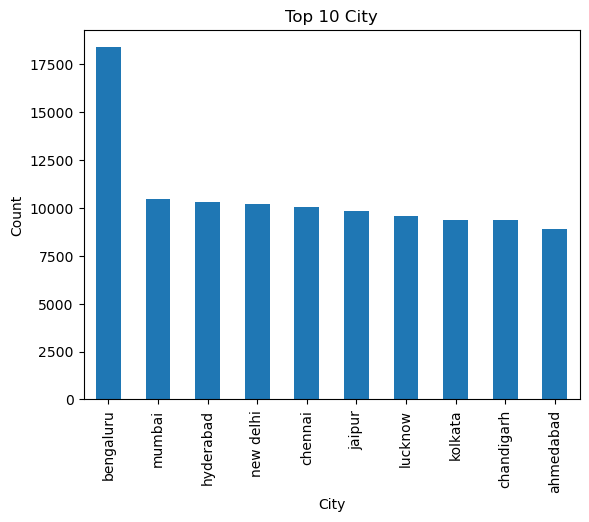

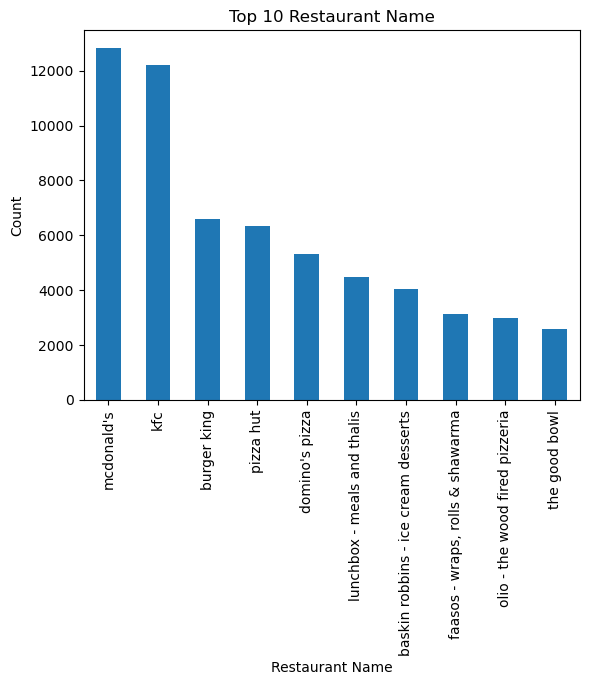

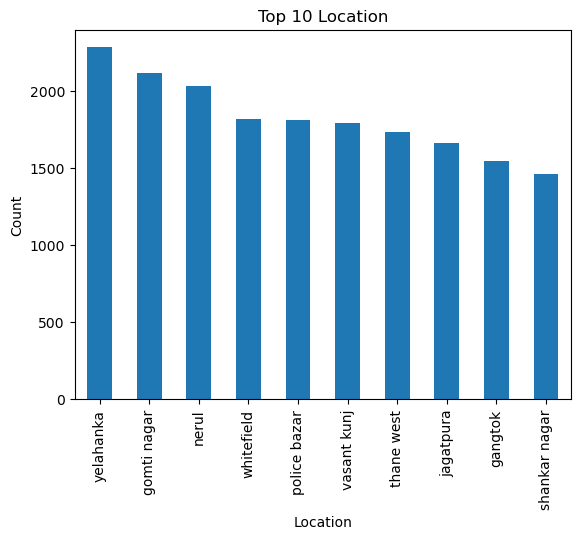

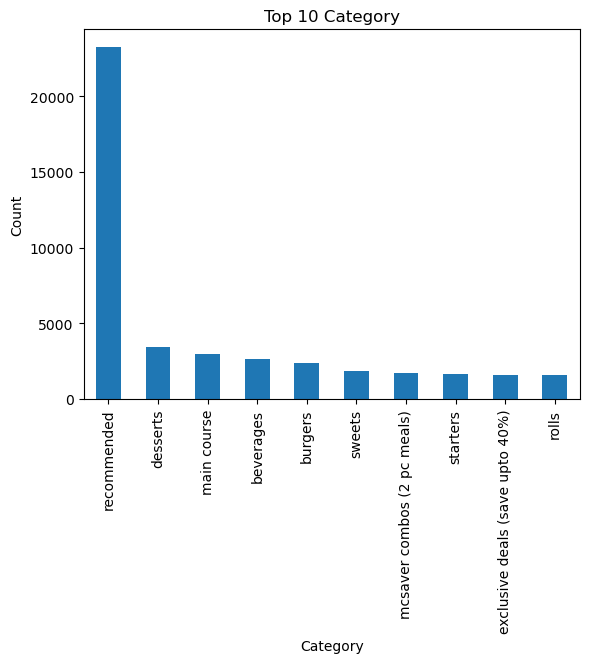

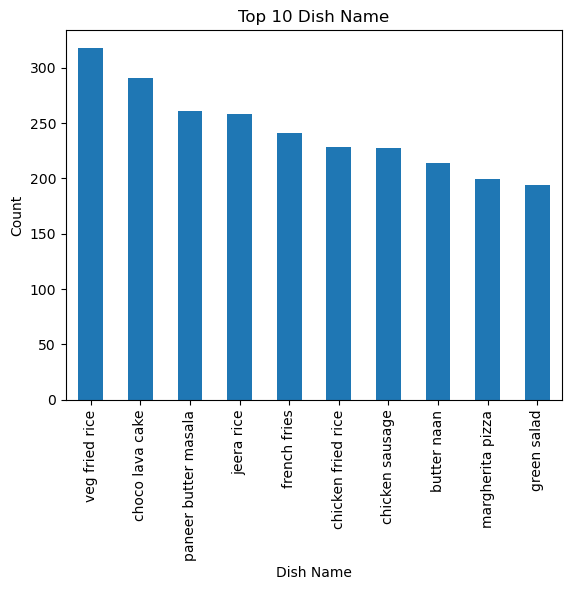

In [24]:
# Identify top 10 most common states, cities, restaurants, categories, and dishes.
import matplotlib.pyplot as plt

for i in cat_col:
    data[i].value_counts().head(10).plot(kind='bar')
    plt.title(f"Top 10 {i.title()}")
    plt.xlabel(i.title())
    plt.ylabel("Count")
    plt.show()

In [25]:
# Look at diversity: are some categories/cities dominating?
for i in cat_col:
    top_10_pct = (
        data[i].value_counts(normalize=True)
        .head(10)
        .sum() * 100
    )
    print(f"Top 10 {i} contribute {top_10_pct:.2f}% of total records")


Top 10 City contribute 55.56% of total records
Top 10 Restaurant Name contribute 31.61% of total records
Top 10 Location contribute 9.54% of total records
Top 10 Category contribute 22.55% of total records
Top 10 Dish Name contribute 1.27% of total records


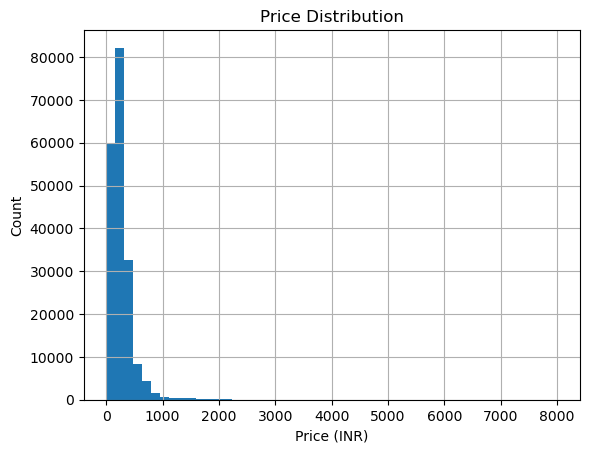

In [46]:
# price distribution
import matplotlib.pyplot as plt

plt.figure()
data["Price (INR)"].hist(bins=50)
plt.xlabel("Price (INR)")
plt.ylabel("Count")
plt.title("Price Distribution")
plt.show()



# Menu item prices are highly right-skewed
# Majority of dishes are priced between ₹50 – ₹300

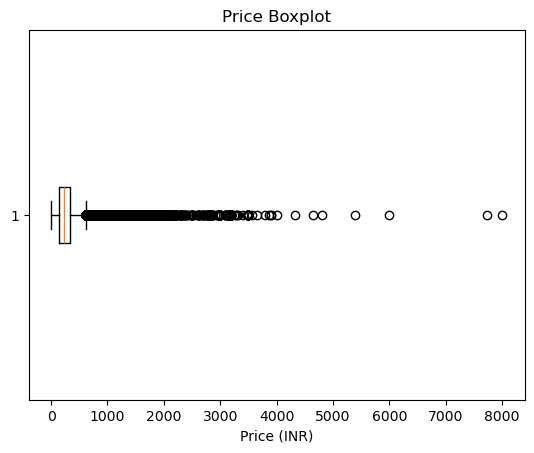

In [47]:
plt.figure()
plt.boxplot(data["Price (INR)"], vert=False)
plt.xlabel("Price (INR)")
plt.title("Price Boxplot")
plt.show()

# Presence of extreme outliers suggests the need for log transformation

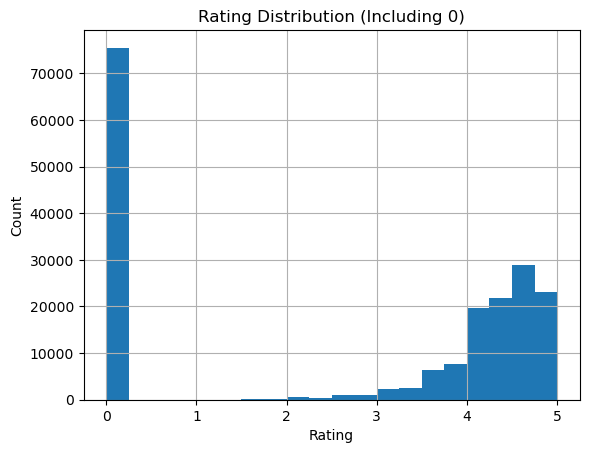

In [55]:
# Rating Distribution including zeros
plt.figure()
data["Rating"].hist(bins=20)
plt.xlabel("Rating")
plt.ylabel("Count")
plt.title("Rating Distribution (Including 0)")
plt.show()

# A large number of menu items have rating = 0, indicating unrated items, not poor quality

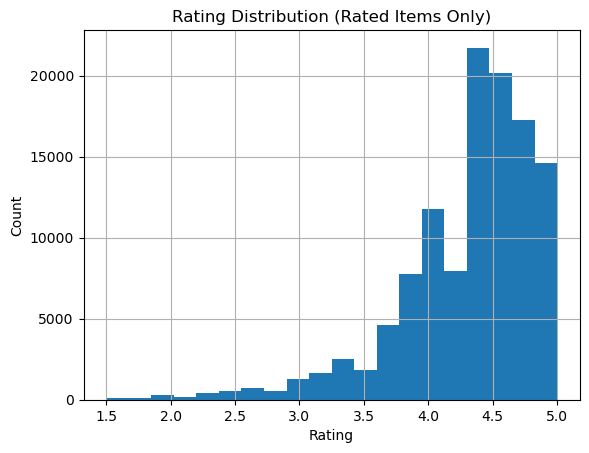

In [56]:
# Rating distribution without zero rating
rated_df = data[data["Rating"] > 0]
plt.figure()
rated_df["Rating"].hist(bins=20)
plt.xlabel("Rating")
plt.ylabel("Count")
plt.title("Rating Distribution (Rated Items Only)")
plt.show()


# Among rated items, most ratings fall between 4.0 and 4.7

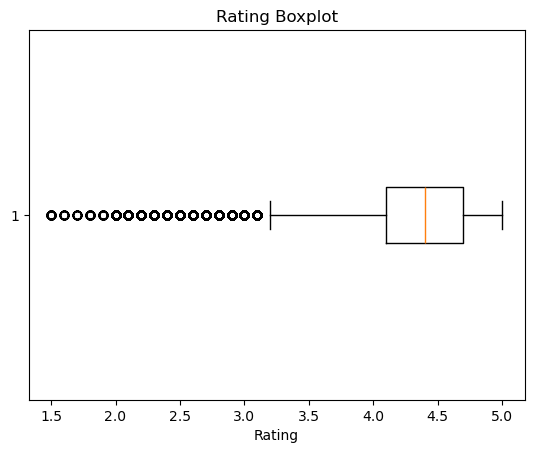

In [54]:
plt.figure()
plt.boxplot(rated_df["Rating"], vert=False)
plt.xlabel("Rating")
plt.title("Rating Boxplot")
plt.show()

### BIVARIATE ANALYSIS

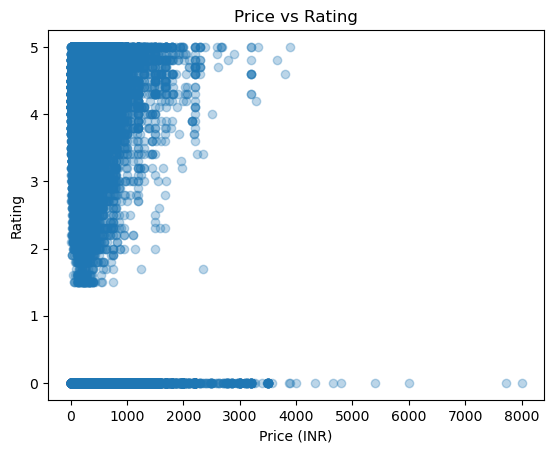

In [57]:
# Price vs Rating
plt.figure()
plt.scatter(data["Price (INR)"], data["Rating"], alpha=0.3)
plt.xlabel("Price (INR)")
plt.ylabel("Rating")
plt.title("Price vs Rating")
plt.show()

# There is no strong correlation between price and rating
# Quality perception is independent of pricing

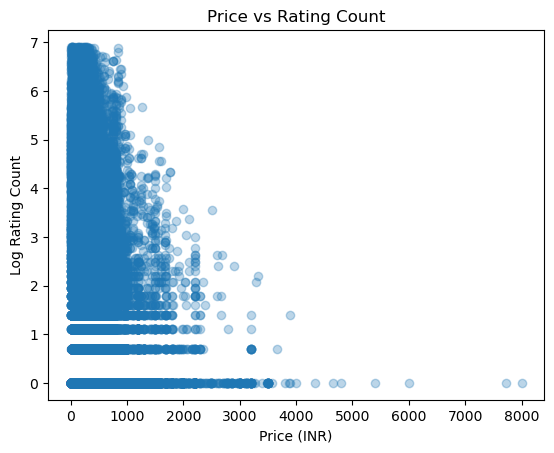

In [58]:
# Price vs Rating Count
plt.figure()
plt.scatter(data["Price (INR)"], np.log1p(data["Rating Count"]), alpha=0.3)    # np.log1p() is used to Reduces skewness
plt.xlabel("Price (INR)")
plt.ylabel("Log Rating Count")
plt.title("Price vs Rating Count")
plt.show()


# Expensive items tend to have lower engagement

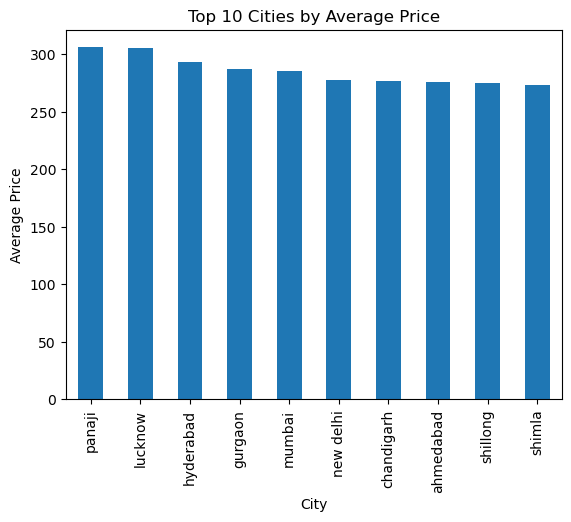

In [59]:
# City vs Average Price
city_price = (data.groupby("City")["Price (INR)"].mean().sort_values(ascending=False).head(10))

plt.figure()
city_price.plot(kind="bar")
plt.xlabel("City")
plt.ylabel("Average Price")
plt.title("Top 10 Cities by Average Price")
plt.show()


# Metro cities show higher average prices
# Cities like Bengaluru, Mumbai, and Delhi dominate menu volume

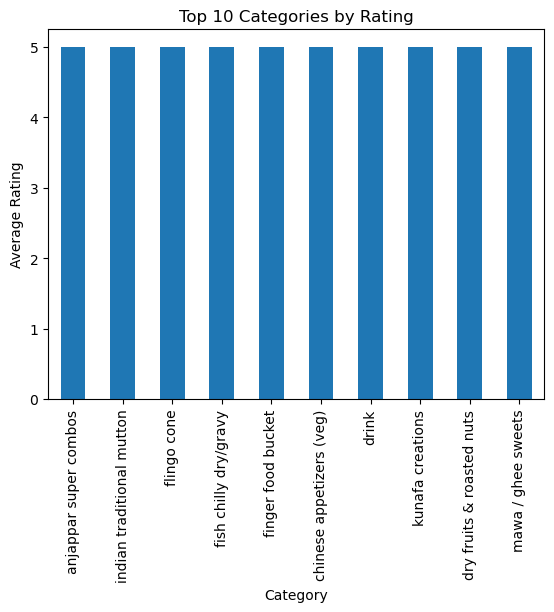

In [38]:
# Category vs Average Rating
category_rating = (
    data[data["Rating Count"] >= 20].groupby("Category")["Rating"].mean().sort_values(ascending=False).head(10))

plt.figure()
category_rating.plot(kind="bar")
plt.xlabel("Category")
plt.ylabel("Average Rating")
plt.title("Top 10 Categories by Rating")
plt.show()


### MULTIVARIATE ANALYSIS

In [60]:
restaurant_summary = (
    data[data["Rating Count"] >= 50].groupby("Restaurant Name").agg(
        avg_price=("Price (INR)", "mean"),
        avg_rating=("Rating", "mean"),
        menu_size=("Dish Name", "count")).sort_values("avg_rating", ascending=False).head(10))

restaurant_summary

# Restaurants with large menu sizes has consistent ratings and tend to dominate customer attention

,avg_price,avg_rating,menu_size
Restaurant Name,,,
sakana,521.333333,4.900000,15
urban nawab,100.000000,4.900000,1
smoor,1350.000000,4.900000,1
minus 30,126.815714,4.885714,7
vipul dudhiya sweets,42.000000,4.866667,3
starbucks coffee,270.000000,4.850000,2
winni cakes & more,99.925000,4.800000,2
food zilla,140.000000,4.800000,1
vijay dairy,52.000000,4.800000,5


In [41]:
category_summary = (data.groupby("Category").agg(
        avg_price=("Price (INR)", "mean"),
        avg_rating=("Rating", "mean"),
        avg_rating_count=("Rating Count", "mean"))
    .sort_values("avg_price", ascending=False).head(10))

category_summary


,avg_price,avg_rating,avg_rating_count
Category,,,
party specials,5520.833333,0.000000,0.000000
party menu for 10pax,4299.000000,2.300000,0.000000
56 bhog,2739.000000,0.000000,0.000000
chef's special assorted platter,2552.000000,0.000000,0.000000
celebration box,2376.000000,0.000000,0.000000
hampers & gift boxes,2270.769231,2.446154,0.769231
family meal box (serves 4 to 6),2115.666667,3.483333,2.666667
mega momos platter,2091.500000,0.000000,0.000000
3d customised cake,2089.000000,0.000000,0.000000


### Focus on mid-priced items for higher engagement

### Premium pricing does not guarantee better customer perception

### Encourage ratings for unrated items to improve trust